# Milestone 1 Project - Bradley Hofmeister & Dominick Devarti
## Part 1: Kalshi Closing Line Odds for the 2025-2026 NBA Regular Season

We will use data from the Sports Reference website stored in 'nba_reg_2526.csv' and the Kalshi prediction market API to get closing line odds for the 2025-2026 NBA regular season.

### 1. Import Modules and NBA Team Dictionary

Start by importing standard python libraries and the `team_to_code` dictionary.

The `team_to_code` dictionary maps NBA teams from their (City / Team name) format in the 'nba_reg_2526.csv' file to their kalshi market ticker abbreviations.

Python Kernal: 3.13.3

In [1]:
import time
import requests
import numpy as np
import pandas as pd
from datetime import date, timedelta


team_to_code = {
    'Atlanta Hawks': 'ATL',
    'Boston Celtics': 'BOS',
    'Brooklyn Nets': 'BKN',
    'Charlotte Hornets': 'CHA',
    'Chicago Bulls': 'CHI',
    'Cleveland Cavaliers': 'CLE',
    'Dallas Mavericks': 'DAL',
    'Denver Nuggets': 'DEN',
    'Detroit Pistons': 'DET',
    'Golden State Warriors': 'GSW',
    'Houston Rockets': 'HOU',
    'Indiana Pacers': 'IND',
    'Los Angeles Clippers': 'LAC',
    'Los Angeles Lakers': 'LAL',
    'Memphis Grizzlies': 'MEM',
    'Miami Heat': 'MIA',
    'Milwaukee Bucks': 'MIL',
    'Minnesota Timberwolves': 'MIN',
    'New Orleans Pelicans': 'NOP',
    'New York Knicks': 'NYK',
    'Oklahoma City Thunder': 'OKC',
    'Orlando Magic': 'ORL',
    'Philadelphia 76ers': 'PHI',
    'Phoenix Suns': 'PHX',
    'Portland Trail Blazers': 'POR',
    'Sacramento Kings': 'SAC',
    'San Antonio Spurs': 'SAS',
    'Toronto Raptors': 'TOR',
    'Utah Jazz': 'UTA',
    'Washington Wizards': 'WAS',
}



### 2. Data Loading and Cleaning

Use the `nba_season_converter` function to create three Pandas DataFrames.

As described and shown in step 3, the Kalshi API has two endpoints we will have to use due to specific time cutoff of 61 days (two months).

1. `full_nba_season_df` is a cleaned full season df that will be used at the end to merge our Kalshi odds data with.
2. `historical_games` is for the full season except later April games (due to API endpoint time cutoff)
3. `april_games` is for any remaining April games. 



In [2]:
def nba_season_converter(data_file):
    '''
    Import csv dataset and create a Pandas DataFrame
    Create and consolidate to one column the start times (in EST) for all regular season games
    Create a 'GameID' column that uses the dataset to match the format of Kalshi market tickers for home teams
    Rename columns in the DataFrame for cleanliness and clarity
    In the original data set there is no 'Winner' column so create one based on which team scored more points
    Create a 'TimeStamp' column of when games started, which will be used later to fetch the closing line price
    '''

    nba_games = pd.read_csv(data_file)
    df = pd.DataFrame(nba_games)

    df['DateTime_ET'] = pd.to_datetime(
        df['Date'] + ' ' + df['Start (ET)'].str.replace('p', ' PM').str.replace('a', ' AM'),
        format='%a %b %d %Y %I:%M %p',
        errors='coerce')
    
    df['GameID'] = ('KXNBAGAME-' +
        df['DateTime_ET'].dt.strftime('%y') +
        df['DateTime_ET'].dt.strftime('%b').str.upper() +
        df['DateTime_ET'].dt.strftime('%d') +
        df['Visitor/Neutral'].map(team_to_code) +
        df['Home/Neutral'].map(team_to_code) + '-' +
        df['Home/Neutral'].map(team_to_code))
       
    df = df.rename(columns={
        'Visitor/Neutral': 'Visitor',
        'PTS': 'Visitor PTS',
        'Home/Neutral': 'Home',
        'PTS.1': 'Home PTS'
        })
    
    df['Winner'] = np.where(df['Visitor PTS'] > df['Home PTS'], df['Visitor'], df['Home'])
    df['TimeStamp'] = (df['DateTime_ET'].dt.tz_localize('US/Eastern').astype('int64') // 1_000_000_000)

    df = df[['GameID', 'DateTime_ET', 'Visitor', 'Visitor PTS', 'Home', 'Home PTS', 'Winner', 'TimeStamp']]

    return df

today = date.today()
date_65_days_ago = today - timedelta(days=61)
cutoff = pd.Timestamp(date_65_days_ago)

# First DF
full_nba_season_df= nba_season_converter('data/nba_reg_2526(full).csv')

# Second DF
df1 = nba_season_converter('data/nba_reg_2526(full).csv')
historical_games = (df1[df1['DateTime_ET'] < cutoff].set_index('GameID')['TimeStamp'].to_dict())

# Third DF
df2 = nba_season_converter('data/nba_reg_2526(full).csv')
april_games = (df2[df2['DateTime_ET'] > cutoff].set_index('GameID')['TimeStamp'].to_dict())



### 3. Fetching Kalshi Closing Line Odds

Here we have two functions that do essentially the same thing - fetch trades placed at the start of NBA games.

Each trade contains several data points but the main one we're focused on is the 'yes_price_dollars', which contains real prices people paid or sold game contracts for.

The numerical value associated with this price is how we determined the closing line odds (price = odds) for each game in the season.

The function `kalshi_historical_cl_prices` uses the Kalshi api endpoint "historical/trades", which is designed to fetch trades on markets from any prior date up until exactly two months ago (61 days).

The function `kalshi_april_cl_prices` uses the Kalshi api endpoint "markets/trades", which is designed to fetch trades on markets that are still open or are closed but within two months (61 days) of today.

** Important Note - If running this notebook anytime after June 12th 2026, only the `kalshi_historical_cl_prices` is needed. **

In [3]:
def kalshi_historical_cl_prices(game_dict, window=550):
    '''
    Takes about 10-15 minutes

    For historical NBA games, this function takes a dictionary of Kalshi market tickers and game start timestamps
        -> It uses these to query the Kalshi markets historical trades endpoint,
           at the start of each game (timestamp) and up to 500 seconds after (window),
           this is to ensure a price is captured if there were no trades placed exactly at the starting time

        -> Then it parses the JSON response to get a list of the trades for each game
        -> For each game, if there were any trades that happened during the specified time period
            -> It will then find the earliest trade by 'created_time'
            -> And from that the 'yes_price_dollars' will be extracted and converted to a float
        -> If there were no trades during this time period then it will revert to 'nan'
        -> This number (or 'nan') and it's corresponding market ticker is then added to the records list
        -> A small sleep delay between requests is used to respect Kalshi's API limits

        -> Finally, it converts the list of dicts from records into a clean pandas DataFrame
    '''
    
    records = []
    for ticker, ts in game_dict.items():
        response = requests.get(
            f"https://external-api.kalshi.com/trade-api/v2/historical/trades",
            params={'ticker': ticker, 'min_ts': ts, 'max_ts': ts + window, 'limit': 100},
            timeout=10)
        
        trades = response.json().get('trades', [])
        if trades:
            first_trade = min(trades, key=lambda t: t['created_time'])
            price = float(first_trade['yes_price_dollars'])
        else:
            price = float('nan')
        records.append({'game_id': ticker, 'price': price})
        time.sleep(0.25)

    return pd.DataFrame(records)



def kalshi_april_cl_prices(game_dict, window=300):
    '''
    Takes about 1-2 minutes

    For the more recent NBA games not included in the historical endpoint yet,
    this function takes a dictionary of Kalshi market tickers and game start timestamps
        -> It uses these to query the Kalshi markets trades endpoint,
           at the start of each game (timestamp) and up to 300 seconds after (window),
           this is to ensure a price is captured if there were no trades placed exactly at the starting time
        
        -> Then it parses the JSON response to get a list of the trades for each game
        -> For each game, if there were any trades that happened during the specified time period
            -> It will then find the earliest trade by 'created_time'
            -> And from that the 'yes_price_dollars' will be extracted and converted to a float
        -> If there were no trades during this time period then it will revert to 'nan'
        -> This number (or 'nan') and it's corresponding market ticker is then added to the records list
        -> A small sleep delay between requests is used to respect Kalshi's API limits

        -> Finally, it converts the list of dicts from records into a clean pandas DataFrame
    '''

    records = []
    for ticker, ts in game_dict.items():
        r = requests.get(
            'https://external-api.kalshi.com/trade-api/v2/markets/trades',
            params={'ticker': ticker, 'min_ts': ts, 'max_ts': ts + window, 'limit': 100},
            timeout=10)
        
        trades = r.json().get('trades', [])
        if trades:
            first_trade = min(trades, key=lambda t: t['created_time'])
            price = float(first_trade['yes_price_dollars'])
        else:
            price = float('nan')
        records.append({'game_id': ticker, 'price': price})
        time.sleep(0.25)
    
    return pd.DataFrame(records)

### 4. Create and Concatenate Closing Line Price DataFrames

First fetch the closing line prices for all the NBA games available in the historical endpoint, then fetch any remaining games, then concatenate them into a single combined DataFrame.

** Important Note - If running this notebook anytime after June 12th 2026, only the first code block with `kalshi_historical_cl_prices` is needed. **

In [4]:
# Fetch closing line prices for all NBA games (October 2025 - Cutoff) (~15mins)
result1 = kalshi_historical_cl_prices(historical_games)
result1

,game_id,price
0,KXNBAGAME-25OCT21HOUOKC-OKC,0.69
1,KXNBAGAME-25OCT21GSWLAL-LAL,0.44
2,KXNBAGAME-25OCT22BKNCHA-CHA,0.66
3,KXNBAGAME-25OCT22CLENYK-NYK,0.47
4,KXNBAGAME-25OCT22MIAORL-ORL,0.76
...,...,...
1211,KXNBAGAME-26APR10MINHOU-HOU,0.81
1212,KXNBAGAME-26APR10MEMUTA-UTA,0.64
1213,KXNBAGAME-26APR10LACPOR-POR,0.54
1214,KXNBAGAME-26APR10GSWSAC-SAC,0.19


In [5]:
# Fetch closing line prices for any remaining NBA games (April 2026) (~2mins)
# Important Note - Skip this step if running this notebook anytime after June 12th 2026
result2 = kalshi_april_cl_prices(april_games)
result2

,game_id,price
0,KXNBAGAME-26APR12ORLBOS-BOS,0.15
1,KXNBAGAME-26APR12WASCLE-CLE,0.81
2,KXNBAGAME-26APR12DETIND-IND,0.10
3,KXNBAGAME-26APR12ATLMIA-MIA,0.80
4,KXNBAGAME-26APR12CHANYK-NYK,0.13
5,KXNBAGAME-26APR12MILPHI-PHI,0.92
6,KXNBAGAME-26APR12BKNTOR-TOR,0.98
7,KXNBAGAME-26APR12CHIDAL-DAL,0.65
8,KXNBAGAME-26APR12MEMHOU-HOU,0.90
9,KXNBAGAME-26APR12GSWLAC-LAC,0.60


In [6]:
# Concatenate the two DataFrames
# Important Note - this step will not be needed if running this notebook anytime after June 12th 2026
combined_df = pd.concat([result1, result2], ignore_index=True)
combined_df

,game_id,price
0,KXNBAGAME-25OCT21HOUOKC-OKC,0.69
1,KXNBAGAME-25OCT21GSWLAL-LAL,0.44
2,KXNBAGAME-25OCT22BKNCHA-CHA,0.66
3,KXNBAGAME-25OCT22CLENYK-NYK,0.47
4,KXNBAGAME-25OCT22MIAORL-ORL,0.76
...,...,...
1226,KXNBAGAME-26APR12UTALAL-LAL,0.91
1227,KXNBAGAME-26APR12NOPMIN-MIN,0.61
1228,KXNBAGAME-26APR12PHXOKC-OKC,0.74
1229,KXNBAGAME-26APR12SACPOR-POR,0.95


### 4. Final Cleaned and Combined DataFrame

Use the function `final_combined_df` to merge the original full NBA season df with the Kalshi price df and drop any NA rows for a cleaned dataset that's ready for the analysis stage.

In [7]:
# If running this file after June 12th 2026 use 'result1' for the second parameter
# If running this file on or before June 12th 2026 use 'combined_df' for the second parameter

def final_combined_df(orig_df, combined_df):
    fc_df = pd.concat([orig_df, combined_df], axis=1)
    fc_df = fc_df.dropna()
    fc_df['Kalshi Odds (Visitor win)'] = 1 - fc_df['price']
    fc_df = fc_df.rename(columns={'price': 'Kalshi Odds (Home win)'})
    fc_df = fc_df.drop(columns=['game_id', 'TimeStamp'])
    fc_df = fc_df[['GameID', 'DateTime_ET',
               'Visitor', 'Visitor PTS', 'Home', 'Home PTS', 'Winner', 
               'Kalshi Odds (Visitor win)', 'Kalshi Odds (Home win)']]
    return fc_df


final_df = final_combined_df(full_nba_season_df, combined_df)
final_df

,GameID,DateTime_ET,Visitor,Visitor PTS,Home,Home PTS,Winner,Kalshi Odds (Visitor win),Kalshi Odds (Home win)
0,KXNBAGAME-25OCT21HOUOKC-OKC,2025-10-21 19:30:00,Houston Rockets,124,Oklahoma City Thunder,125,Oklahoma City Thunder,0.31,0.69
1,KXNBAGAME-25OCT21GSWLAL-LAL,2025-10-21 22:00:00,Golden State Warriors,119,Los Angeles Lakers,109,Golden State Warriors,0.56,0.44
2,KXNBAGAME-25OCT22BKNCHA-CHA,2025-10-22 19:00:00,Brooklyn Nets,117,Charlotte Hornets,136,Charlotte Hornets,0.34,0.66
3,KXNBAGAME-25OCT22CLENYK-NYK,2025-10-22 19:00:00,Cleveland Cavaliers,111,New York Knicks,119,New York Knicks,0.53,0.47
4,KXNBAGAME-25OCT22MIAORL-ORL,2025-10-22 19:00:00,Miami Heat,121,Orlando Magic,125,Orlando Magic,0.24,0.76
...,...,...,...,...,...,...,...,...,...
1226,KXNBAGAME-26APR12UTALAL-LAL,2026-04-12 20:30:00,Utah Jazz,107,Los Angeles Lakers,131,Los Angeles Lakers,0.09,0.91
1227,KXNBAGAME-26APR12NOPMIN-MIN,2026-04-12 20:30:00,New Orleans Pelicans,126,Minnesota Timberwolves,132,Minnesota Timberwolves,0.39,0.61
1228,KXNBAGAME-26APR12PHXOKC-OKC,2026-04-12 20:30:00,Phoenix Suns,135,Oklahoma City Thunder,103,Phoenix Suns,0.26,0.74
1229,KXNBAGAME-26APR12SACPOR-POR,2026-04-12 20:30:00,Sacramento Kings,110,Portland Trail Blazers,122,Portland Trail Blazers,0.05,0.95


In [8]:
final_df.info()
final_df.to_csv('final_combined.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
Index: 1229 entries, 0 to 1230
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   GameID                     1229 non-null   object        
 1   DateTime_ET                1229 non-null   datetime64[ns]
 2   Visitor                    1229 non-null   object        
 3   Visitor PTS                1229 non-null   int64         
 4   Home                       1229 non-null   object        
 5   Home PTS                   1229 non-null   int64         
 6   Winner                     1229 non-null   object        
 7   Kalshi Odds (Visitor win)  1229 non-null   float64       
 8   Kalshi Odds (Home win)     1229 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 96.0+ KB


## Part 2: ELO Model & Market Calibration Analysis

Comparing Kalshi prediction-market closing odds against an ELO-based statistical
model for 2025-26 NBA regular-season game outcomes.

Key outputs:
- **Brier Score** comparison (lower = better calibrated)
- **Calibration Curve** (Reliability Diagram)
- **Edge Distribution** histogram

In [10]:
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

INITIAL_ELO = 1500
K_FACTOR = 20
HOME_ADVANTAGE = 75
DATA_PATH = 'final_combined.csv'


### 1. Data Loading & Cleaning

`final_combined.csv` is merged output: Kalshi closing odds + game results.

In [11]:
df = pd.read_csv(DATA_PATH)
df['home_win'] = (df['Winner'] == df['Home']).astype(int)
df.head(3)


,GameID,DateTime_ET,Visitor,Visitor PTS,Home,Home PTS,Winner,Kalshi Odds (Visitor win),Kalshi Odds (Home win),home_win
0,KXNBAGAME-25OCT21HOUOKC-OKC,2025-10-21 19:30:00,Houston Rockets,124,Oklahoma City Thunder,125,Oklahoma City Thunder,0.31,0.69,1
1,KXNBAGAME-25OCT21GSWLAL-LAL,2025-10-21 22:00:00,Golden State Warriors,119,Los Angeles Lakers,109,Golden State Warriors,0.56,0.44,0
2,KXNBAGAME-25OCT22BKNCHA-CHA,2025-10-22 19:00:00,Brooklyn Nets,117,Charlotte Hornets,136,Charlotte Hornets,0.34,0.66,1


### 2. ELO Rating Model

All 30 teams start at **ELO 1500**. After every game the winner gains and the
loser loses ELO points (K = 20). A fixed **home-court advantage of 75 ELO points**
is applied when computing pre-game win probabilities (≈ 60.7 % for perfectly
matched teams at home).

$$P(\text{home wins}) = \frac{1}{1 + 10^{(\text{ELO}_{\text{vis}} - (\text{ELO}_{\text{home}} + 75)) / 400}}$$

In [12]:
elo_ratings = {}

def get_elo(team):
    return elo_ratings.get(team, INITIAL_ELO)

def elo_win_prob(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def elo_calculations(df):
    pre_elo_home, pre_elo_vis, elo_p_home = [], [], []

    for _, row in df.iterrows():
        home, vis = row['Home'], row['Visitor']
        eh, ev = get_elo(home), get_elo(vis)

        p = elo_win_prob(eh + HOME_ADVANTAGE, ev)
        elo_p_home.append(p)
        pre_elo_home.append(eh)
        pre_elo_vis.append(ev)

        exp_h = elo_win_prob(eh, ev)
        actual_h = row['home_win']
        elo_ratings[home] = eh + K_FACTOR * (actual_h - exp_h)
        elo_ratings[vis]  = ev + K_FACTOR * ((1 - actual_h) - (1 - exp_h))

    df['elo_prob_home'] = elo_p_home
    df['pre_game_elo_home'] = pre_elo_home
    df['pre_game_elo_vis'] = pre_elo_vis
    
    return df

df = elo_calculations(df)
df

,GameID,DateTime_ET,Visitor,Visitor PTS,Home,Home PTS,Winner,Kalshi Odds (Visitor win),Kalshi Odds (Home win),home_win,elo_prob_home,pre_game_elo_home,pre_game_elo_vis
0,KXNBAGAME-25OCT21HOUOKC-OKC,2025-10-21 19:30:00,Houston Rockets,124,Oklahoma City Thunder,125,Oklahoma City Thunder,0.31,0.69,1,0.606288,1500.000000,1500.000000
1,KXNBAGAME-25OCT21GSWLAL-LAL,2025-10-21 22:00:00,Golden State Warriors,119,Los Angeles Lakers,109,Golden State Warriors,0.56,0.44,0,0.606288,1500.000000,1500.000000
2,KXNBAGAME-25OCT22BKNCHA-CHA,2025-10-22 19:00:00,Brooklyn Nets,117,Charlotte Hornets,136,Charlotte Hornets,0.34,0.66,1,0.606288,1500.000000,1500.000000
3,KXNBAGAME-25OCT22CLENYK-NYK,2025-10-22 19:00:00,Cleveland Cavaliers,111,New York Knicks,119,New York Knicks,0.53,0.47,1,0.606288,1500.000000,1500.000000
4,KXNBAGAME-25OCT22MIAORL-ORL,2025-10-22 19:00:00,Miami Heat,121,Orlando Magic,125,Orlando Magic,0.24,0.76,1,0.606288,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,KXNBAGAME-26APR12UTALAL-LAL,2026-04-12 20:30:00,Utah Jazz,107,Los Angeles Lakers,131,Los Angeles Lakers,0.09,0.91,1,0.892584,1606.286155,1313.454095
1225,KXNBAGAME-26APR12NOPMIN-MIN,2026-04-12 20:30:00,New Orleans Pelicans,126,Minnesota Timberwolves,132,Minnesota Timberwolves,0.39,0.61,1,0.785846,1555.462401,1404.618175
1226,KXNBAGAME-26APR12PHXOKC-OKC,2026-04-12 20:30:00,Phoenix Suns,135,Oklahoma City Thunder,103,Phoenix Suns,0.26,0.74,0,0.833937,1709.069149,1503.724993
1227,KXNBAGAME-26APR12SACPOR-POR,2026-04-12 20:30:00,Sacramento Kings,110,Portland Trail Blazers,122,Portland Trail Blazers,0.05,0.95,1,0.789536,1518.716238,1364.038411


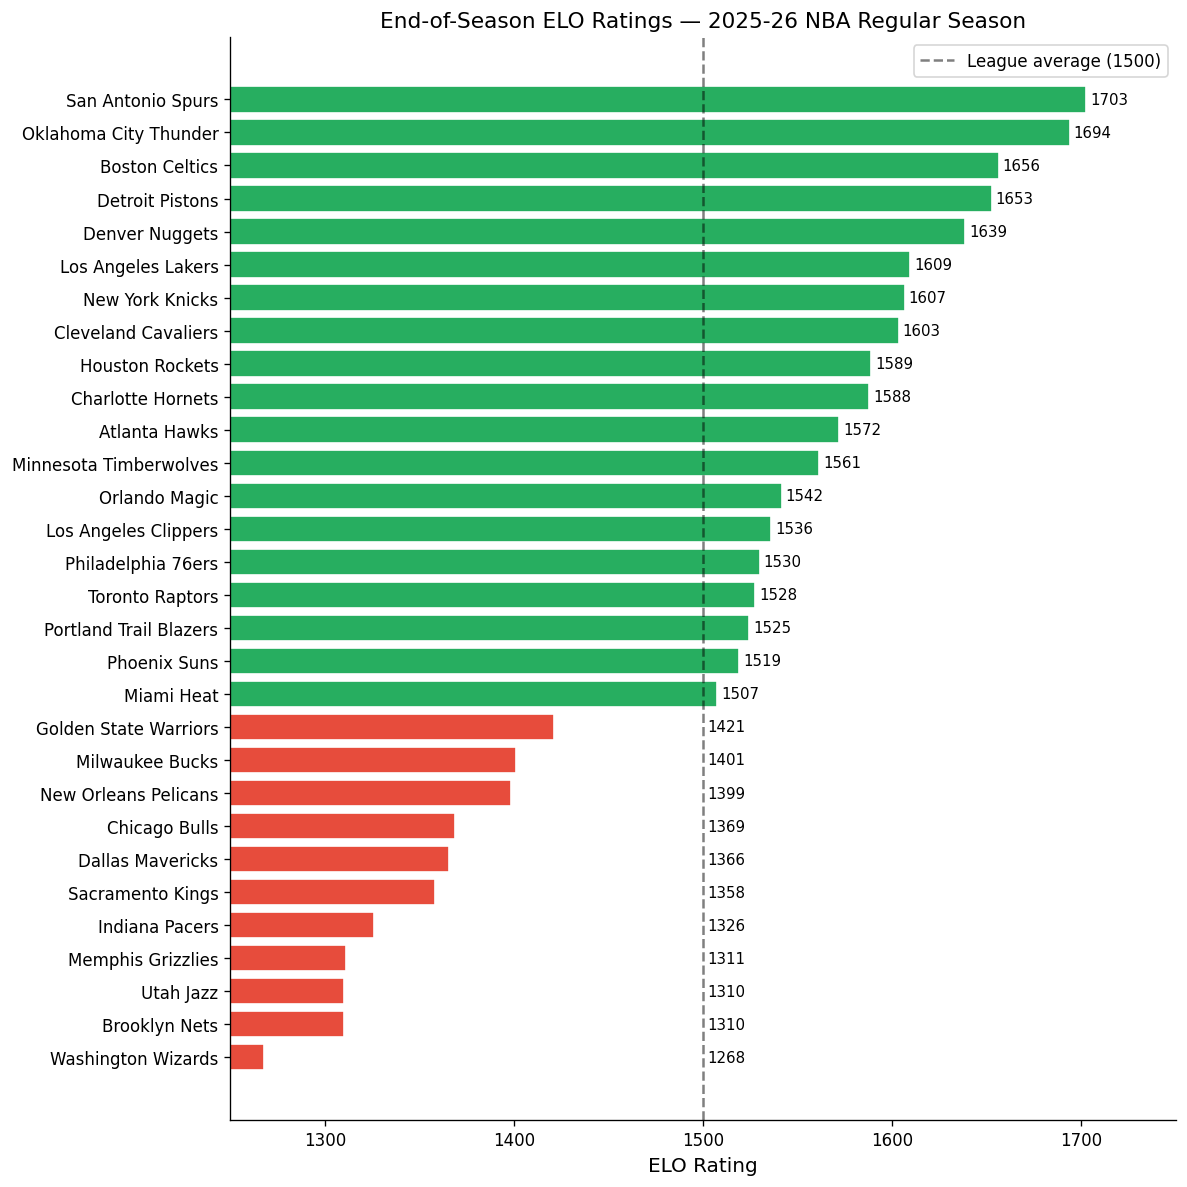

In [13]:
# Visualization of end-of-season ELO ratings 
elo_df = (
    pd.Series(elo_ratings, name='ELO')
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={'index': 'Team'})
)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#27ae60' if e >= 1500 else '#e74c3c' for e in elo_df['ELO']]
bars = ax.barh(elo_df['Team'], elo_df['ELO'], color=colors, edgecolor='white')
ax.axvline(1500, color='black', linestyle='--', alpha=0.5, lw=1.5, label='League average (1500)')
for bar, val in zip(bars, elo_df['ELO']):
    ax.text(max(val, 1500) + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9)
ax.set_xlabel('ELO Rating', fontsize=12)
ax.set_title('End-of-Season ELO Ratings — 2025-26 NBA Regular Season', fontsize=13)
ax.legend()
ax.set_xlim(1250, 1750)
plt.tight_layout()
plt.savefig('elo_standings.png', dpi=150, bbox_inches='tight')
plt.show()


### 3. Brier Score Comparison

$$BS = \frac{1}{N}\sum_{i=1}^{N}(\hat{p}_i - o_i)^2$$

Lower is better. The naive baseline (always predict 0.5) gives BS = 0.250.

In [14]:
def brier_score(y_true, y_pred):
    return float(np.mean((np.asarray(y_pred) - np.asarray(y_true)) ** 2))

bs_kalshi = brier_score(df['home_win'], df['Kalshi Odds (Home win)'])
bs_elo    = brier_score(df['home_win'], df['elo_prob_home'])
bs_naive  = brier_score(df['home_win'], [0.5] * len(df))

summary = pd.DataFrame({
    'Model':        ['Kalshi Market', 'ELO Model', 'Naive (0.5)'],
    'Brier Score':  [bs_kalshi, bs_elo, bs_naive],
    'vs. Naive':    [bs_kalshi - bs_naive, bs_elo - bs_naive, 0.0],
})
print(summary.sort_values('Brier Score').to_string(index=False))

        Model  Brier Score  vs. Naive
Kalshi Market     0.194419  -0.055581
    ELO Model     0.213402  -0.036598
  Naive (0.5)     0.250000   0.000000


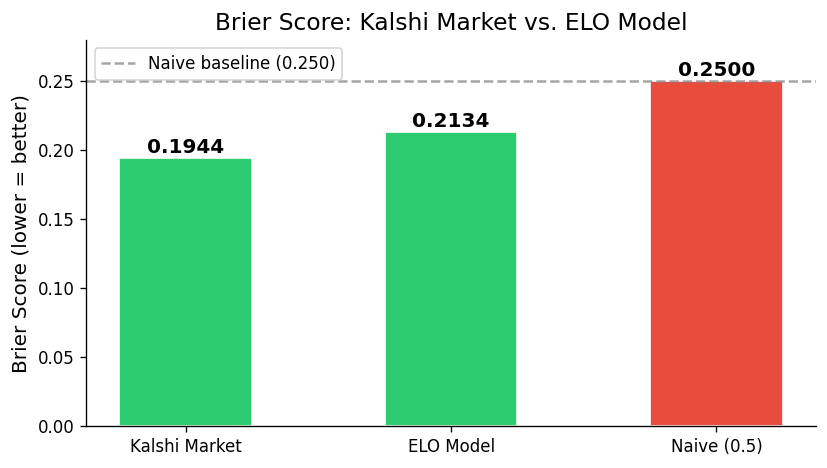

In [15]:
##### BRIER SCORES KALSHI VS ELO MODEL VISUALIZATION
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71' if v < bs_naive else '#e74c3c' for v in [bs_kalshi, bs_elo, bs_naive]]
bars = ax.bar(['Kalshi Market', 'ELO Model', 'Naive (0.5)'], [bs_kalshi, bs_elo, bs_naive], color=colors, width=0.5, edgecolor='white')
ax.axhline(bs_naive, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Naive baseline (0.250)')
for bar, val in zip(bars, [bs_kalshi, bs_elo, bs_naive]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001, f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Brier Score (lower = better)', fontsize=12)
ax.set_title('Brier Score: Kalshi Market vs. ELO Model', fontsize=14)
ax.set_ylim(0, 0.28)
ax.legend()

plt.tight_layout()
plt.savefig('brier_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Calibration Curve (Reliability Diagram)

A perfectly calibrated model lies on the diagonal **y = x**. Points above the
diagonal → **underconfident** (events happen more than predicted). Points below →
**overconfident**. Bubble size = number of games in that probability bin.

In [16]:
def calibration_buckets(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    centers, obs_freqs, counts = [], [], []
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_pred >= lo) & (y_pred < hi)
        n = mask.sum()
        centers.append((lo + hi) / 2)
        obs_freqs.append(y_true[mask].mean() if n > 0 else np.nan)
        counts.append(n)
    return np.array(centers), np.array(obs_freqs), np.array(counts)

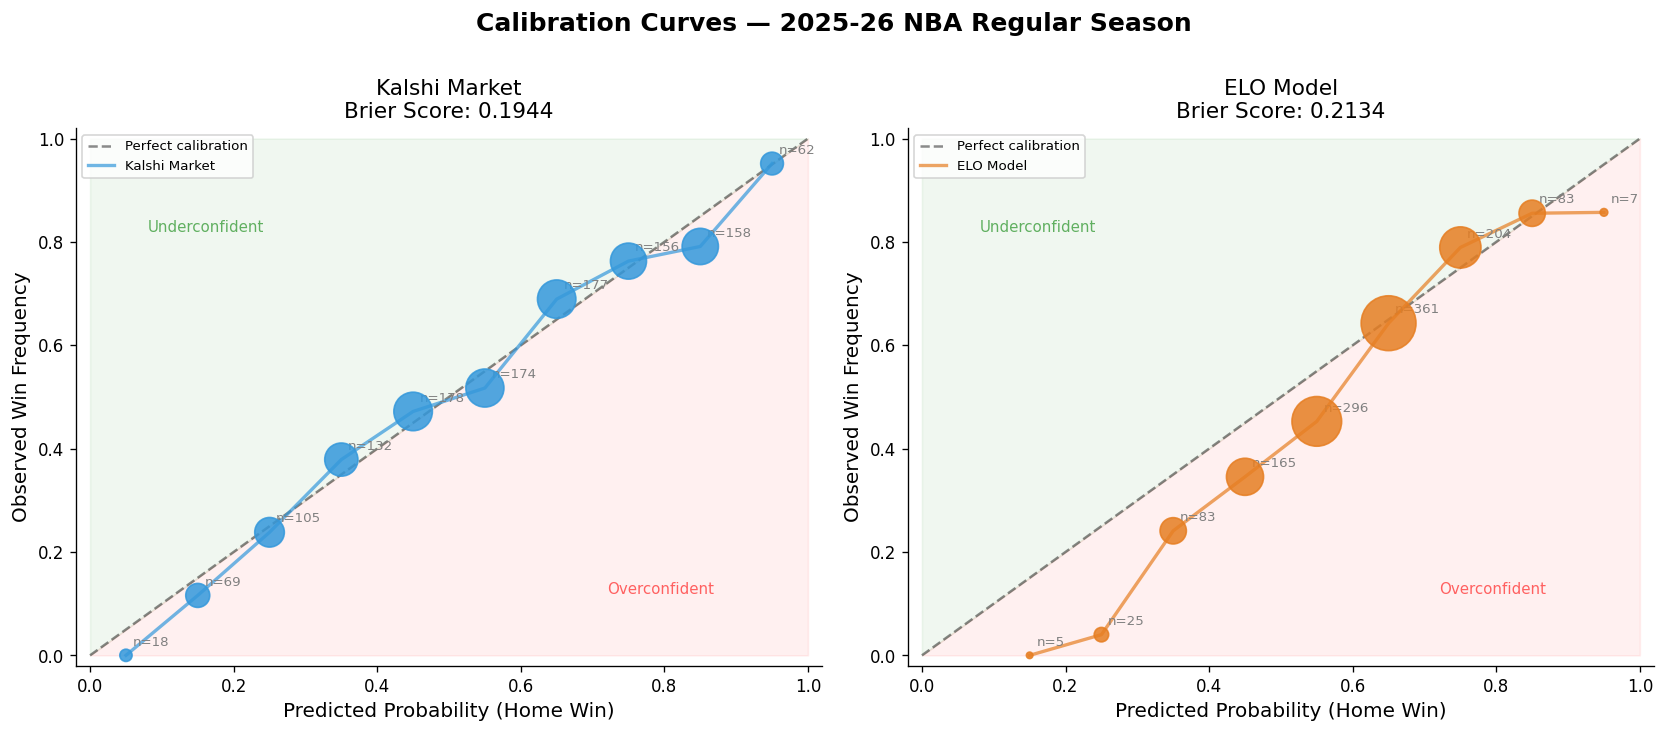

In [17]:
##### CALIBRATION VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
y_true = df['home_win'].values
for ax, (probs, label, color) in zip(axes, [(df['Kalshi Odds (Home win)'].values, 'Kalshi Market', '#3498db'), (df['elo_prob_home'].values,    'ELO Model',     '#e67e22'),]):
    centers, obs, counts = calibration_buckets(y_true, probs)
    valid = ~np.isnan(obs)

    ax.plot([0,1],[0,1], 'k--', alpha=0.45, lw=1.5, label='Perfect calibration')
    ax.fill_between([0,1],[0,1],[1,1], alpha=0.06, color='green')
    ax.fill_between([0,1],[0,0],[0,1], alpha=0.06, color='red')

    ax.scatter(centers[valid], obs[valid], s=counts[valid]*3, c=color, alpha=0.85, zorder=5)
    ax.plot(centers[valid], obs[valid], color=color, alpha=0.7, lw=2, label=label)

    for x, y, n in zip(centers[valid], obs[valid], counts[valid]):
        ax.annotate(f'n={n}', (x, y), xytext=(4, 6), textcoords='offset points', fontsize=8, color='gray')

    bs = brier_score(y_true, probs)
    ax.set_xlabel('Predicted Probability (Home Win)', fontsize=12)
    ax.set_ylabel('Observed Win Frequency',           fontsize=12)
    ax.set_title(f'{label}\nBrier Score: {bs:.4f}',  fontsize=13)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.text(0.72, 0.12, 'Overconfident', color='red',   fontsize=9, alpha=0.6)
    ax.text(0.08, 0.82, 'Underconfident', color='green', fontsize=9, alpha=0.6)

plt.suptitle('Calibration Curves — 2025-26 NBA Regular Season', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Edge Distribution Histogram

**Edge** = ELO model's home-win probability minus Kalshi's home-win probability.

- Positive edge → ELO thinks the home team is *more* likely to win than the market does
- Negative edge → ELO thinks the visitor is *underpriced* by the market
- Wide distribution → the model and market frequently disagree

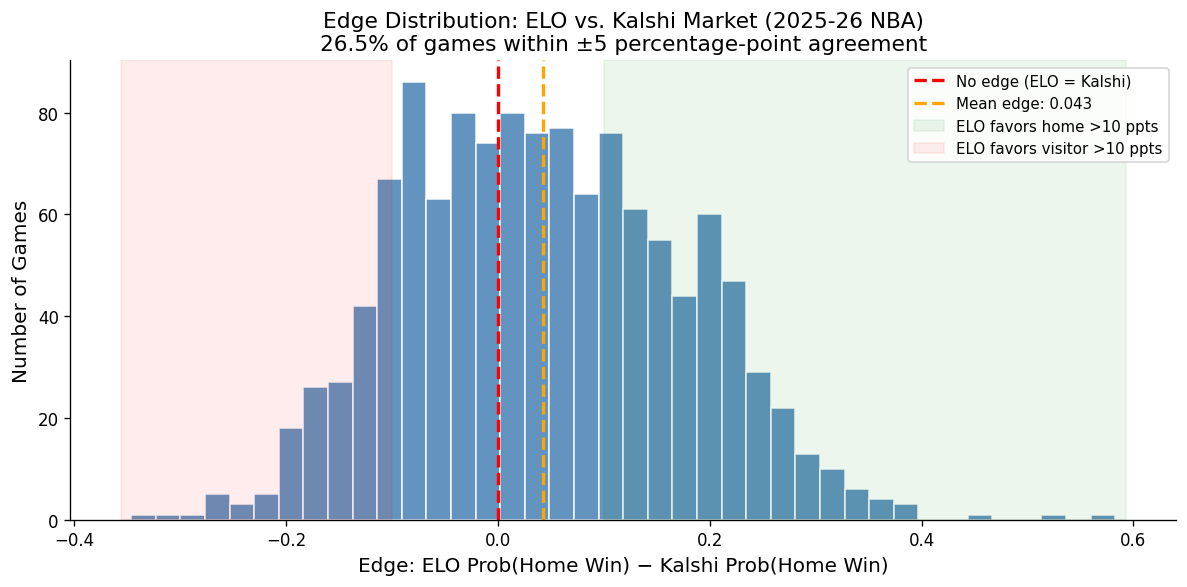

Edge summary statistics:
count    1229.0000
mean        0.0428
std         0.1310
min        -0.3461
25%        -0.0597
50%         0.0379
75%         0.1356
max         0.5827
Name: edge, dtype: float64


In [18]:
df['edge'] = df['elo_prob_home'] - df['Kalshi Odds (Home win)']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['edge'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red',    lw=2, linestyle='--', label='No edge (ELO = Kalshi)')
ax.axvline(df['edge'].mean(),   color='orange', lw=2, linestyle='--',label=f'Mean edge: {df["edge"].mean():.3f}')
ax.axvspan( 0.10, df['edge'].max() + 0.01, alpha=0.07, color='green',label='ELO favors home >10 ppts')
ax.axvspan(df['edge'].min() - 0.01, -0.10, alpha=0.07, color='red',label='ELO favors visitor >10 ppts')

pct_agree = (df['edge'].abs() < 0.05).mean() * 100
ax.set_xlabel('Edge: ELO Prob(Home Win) − Kalshi Prob(Home Win)', fontsize=12)
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_title(
    f'Edge Distribution: ELO vs. Kalshi Market (2025-26 NBA)\n'
    f'{pct_agree:.1f}% of games within ±5 percentage-point agreement',
    fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('edge_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Edge summary statistics:")
print(df['edge'].describe().round(4))

End of Project Notebook